In [ ]:
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

import src.data_prep as dp
import src.power_flow as pfo
import src.config as cfg

# --- Silence verbose loggers ------------------------------------------------
for name in ("pypsa", "linopy", "highspy", "gurobipy"):
    logging.getLogger(name).setLevel(logging.WARNING)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# --- Publication-ready Matplotlib style -------------------------------------
plt.rcParams.update({
    "font.family":           "serif",
    "font.size":             10,
    "axes.labelsize":        11,
    "axes.titlesize":        11,
    "xtick.labelsize":        9,
    "ytick.labelsize":        9,
    "legend.fontsize":        8,
    #"legend.title_fontsize":  8,
    "figure.dpi":           130,
    "axes.grid":           True,
    "grid.linestyle":      "--",
    "grid.alpha":          0.35,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "savefig.dpi":         300,
    "savefig.bbox":     "tight",
})


In [90]:
price=pd.read_csv('/Users/eliotsouthon/Desktop/Alesund_Simulation_cost/data/dataset.csv')
price_new=pd.read_csv('/Users/eliotsouthon/Desktop/Alesund_Simulation_cost/data/raw/price_EUR_MWh/energy-charts_Electricity_production_and_spot_prices_in_Norway_in_2024.csv')
price_new=price_new[['Date (GMT+1)','Day Ahead Auction (NO3)']]
price_new

,Date (GMT+1),Day Ahead Auction (NO3)
0,NaN,"Price (EUR/MWh, EUR/tCO2)"
1,2024-01-01T00:00+01:00,29.56
2,2024-01-01T01:00+01:00,28.46
3,2024-01-01T02:00+01:00,26.66
4,2024-01-01T03:00+01:00,24.48
...,...,...
8780,2024-12-31T19:00+01:00,10.17
8781,2024-12-31T20:00+01:00,10.64
8782,2024-12-31T21:00+01:00,7.13
8783,2024-12-31T22:00+01:00,7.16


In [91]:
import pandas as pd
import numpy as np
df=price_new
# 1. Supprimer la première ligne (index 0) et réinitialiser les index
df = df.iloc[1:].reset_index(drop=True)

# 2. Renommer les colonnes
df.columns = ['Date', 'price_EUR_MWh']

# 3. Convertir la colonne de prix en type numérique
# (Nécessaire car la première ligne contenait du texte, ce qui a typé la colonne en 'object')
df['price_EUR_MWh'] = pd.to_numeric(df['price_EUR_MWh'], errors='coerce')

# 4. Transformer la colonne Date pour garder l'heure locale au bon format
# On extrait les 16 premiers caractères (YYYY-MM-DDTHH:MM) pour ignorer le fuseau horaire (+01:00)
# afin d'éviter tout décalage d'heure involontaire lors de la conversion.
df['Date'] = pd.to_datetime(df['Date'].str[:16].str.replace('T', ' '))
df['Date'] = df['Date'].dt.strftime('%Y-%m-%d %H:%M:%S')

# 5. Interpolation linéaire pour remplir les valeurs manquantes (NaN)
df['price_EUR_MWh'] = df['price_EUR_MWh'].interpolate(method='linear')

# Affichage du résultat
print(df)

                     Date  price_EUR_MWh
0     2024-01-01 00:00:00          29.56
1     2024-01-01 01:00:00          28.46
2     2024-01-01 02:00:00          26.66
3     2024-01-01 03:00:00          24.48
4     2024-01-01 04:00:00          24.01
...                   ...            ...
8779  2024-12-31 19:00:00          10.17
8780  2024-12-31 20:00:00          10.64
8781  2024-12-31 21:00:00           7.13
8782  2024-12-31 22:00:00           7.16
8783  2024-12-31 23:00:00          12.85

[8784 rows x 2 columns]


In [ ]:
df['Date'][0]

'2024-01-01 00:00:00'

Aperçu des données préparées :
                     price_EUR_MWh
Date                              
2024-01-01 00:00:00          29.56
2024-01-01 01:00:00          28.46
2024-01-01 02:00:00          26.66
2024-01-01 03:00:00          24.48
2024-01-01 04:00:00          24.01


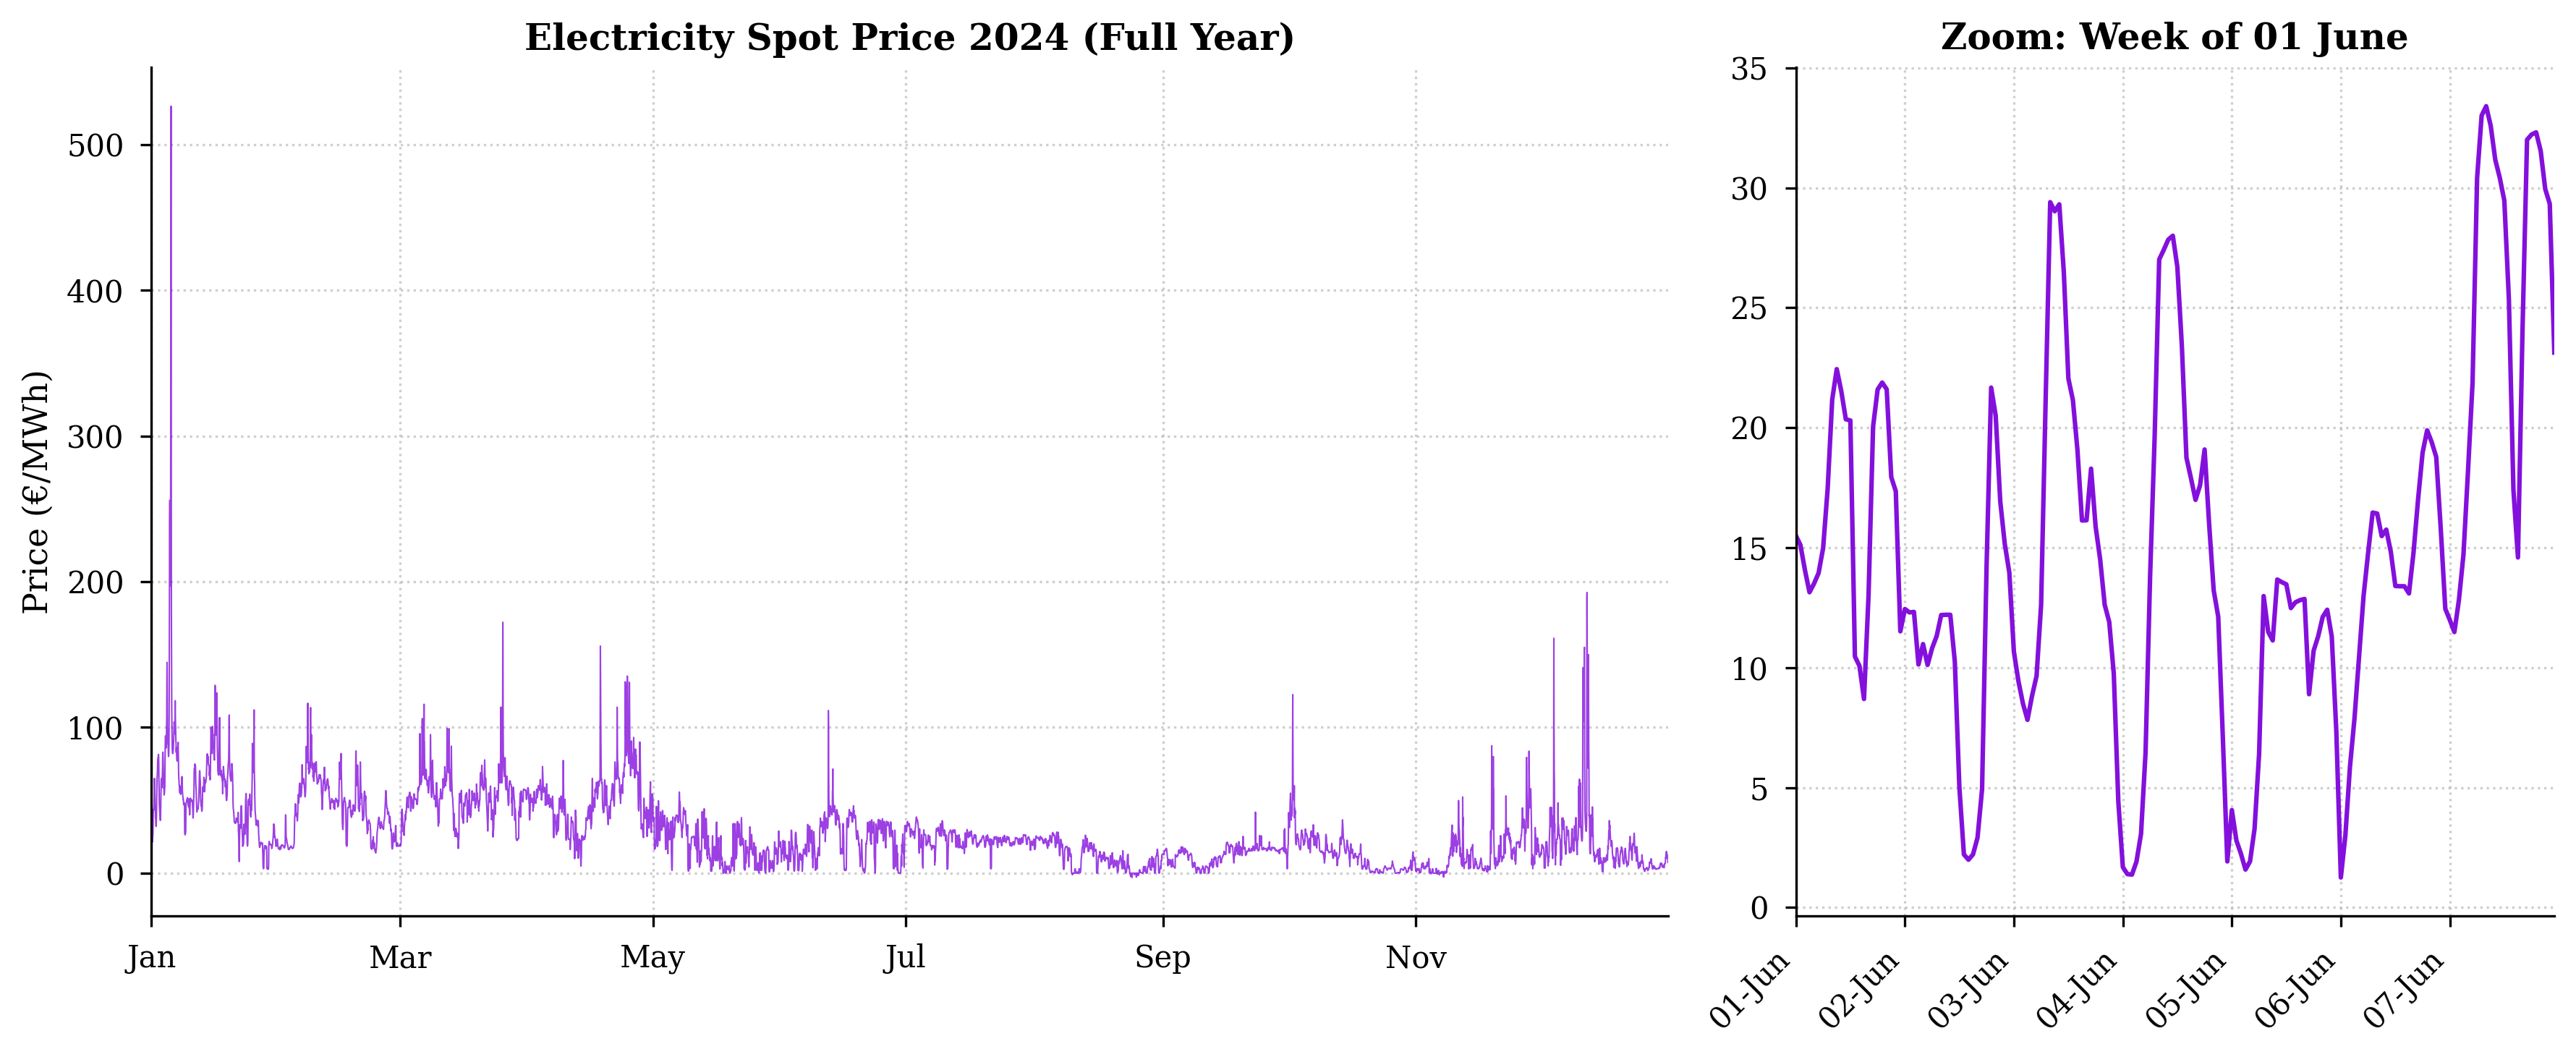

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==================== 1. PREPARATION DES DONNEES ====================
# (On suppose que 'price_new' existe déjà dans votre environnement)
df = price_new.copy()

# 1. Supprimer la première ligne (index 0) et réinitialiser les index
df = df.iloc[1:].reset_index(drop=True)

# 2. Renommer les colonnes
df.columns = ['Date', 'price_EUR_MWh']

# 3. Convertir la colonne de prix en type numérique
df['price_EUR_MWh'] = pd.to_numeric(df['price_EUR_MWh'], errors='coerce')

# 4. Transformer la colonne Date et la définir comme Index
# On extrait les 16 premiers caractères pour ignorer le fuseau horaire
df['Date'] = pd.to_datetime(df['Date'].astype(str).str[:16].str.replace('T', ' '))
# IMPORTANT : On définit la date comme index pour que le graphique puisse lire le temps
df.set_index('Date', inplace=True)

# 5. Interpolation linéaire pour remplir les valeurs manquantes (NaN)
df['price_EUR_MWh'] = df['price_EUR_MWh'].interpolate(method='linear')

print("Aperçu des données préparées :")
print(df.head())

# ==================== 2. CONFIGURATION DU ZOOM ====================
# Définition des périodes de Zoom (Assurez-vous que ces dates existent dans votre DataFrame)
zoom_start = '2024-06-01'
zoom_end = '2024-06-07'

# Création du dataframe zoomé
df_zoom = df.loc[zoom_start:zoom_end]

# ==================== 3. CONFIGURATION DU STYLE ====================
plt.style.use('seaborn-v0_8-paper')
params = {
    'font.family': 'serif',
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'font.size': 11,
    #'legend.fontsize': 9,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300,
    'savefig.bbox': 'tight'
}
plt.rcParams.update(params)

# ==================== 4. FONCTION DE PLOT ====================
def create_scientific_plot(df_year, df_zoom, columns, labels, colors, title, ylabel, kind='line', filename=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [2, 1]})
    
    # --- Left Plot: Full Year ---
    if kind == 'stack':
        ax1.stackplot(df_year.index, [df_year[c] for c in columns], labels=labels, colors=colors, alpha=0.9, edgecolor='white', linewidth=0.2)
        ax2.stackplot(df_zoom.index, [df_zoom[c] for c in columns], labels=labels, colors=colors, alpha=0.9, edgecolor='white', linewidth=0.2)
    else:
        ax1.plot(df_year.index, df_year[columns], color=colors[0], linewidth=0.5, alpha=0.8, label=labels[0])
        ax2.plot(df_zoom.index, df_zoom[columns], color=colors[0], linewidth=1.5, label=labels[0])

    # --- Formatting Axis 1 (Full Year) ---
    ax1.set_title(f"{title} (Full Year)", fontweight='bold') 
    ax1.set_ylabel(ylabel)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.set_xlim(df_year.index.min(), df_year.index.max())
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    # --- Formatting Axis 2 (Zoom) ---
    zoom_date_obj = pd.to_datetime(zoom_start)
    zoom_title_str = zoom_date_obj.strftime('%d %B')
    
    ax2.set_title(f"Zoom: Week of {zoom_title_str}", fontweight='bold')
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.set_xlim(pd.to_datetime(zoom_start), pd.to_datetime(zoom_end) + pd.Timedelta(hours=23))
    
    # Format x-axis
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Common Legend
    #if kind == 'stack':
    #    handles, lbls = ax1.get_legend_handles_labels()
    #    fig.legend(handles[::-1], lbls[::-1], loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False)
    #    plt.subplots_adjust(bottom=0.25)
    #else:
    #    handles, lbls = ax2.get_legend_handles_labels()
    #    fig.legend(handles, lbls, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=1, frameon=False)
    #    plt.subplots_adjust(bottom=0.2)

    plt.tight_layout()
    
    if filename:
        plt.savefig(filename)
        
    plt.show()

# ==================== 5. EXECUTION DU PLOT ====================
colonne_spot = 'price_EUR_MWh'
label_spot = ['Spot Price']
couleur_spot = ["#8310dc"] # Bleu classique

create_scientific_plot(
    df_year=df,
    df_zoom=df_zoom,
    columns=colonne_spot,
    labels=label_spot,
    colors=couleur_spot,
    title='Electricity Spot Price 2024',
    ylabel='Price (€/MWh)',
    kind='line'
)

In [108]:
df.reset_index()

,Date,price_EUR_MWh
0,2024-01-01 00:00:00,29.56
1,2024-01-01 01:00:00,28.46
2,2024-01-01 02:00:00,26.66
3,2024-01-01 03:00:00,24.48
4,2024-01-01 04:00:00,24.01
...,...,...
8779,2024-12-31 19:00:00,10.17
8780,2024-12-31 20:00:00,10.64
8781,2024-12-31 21:00:00,7.13
8782,2024-12-31 22:00:00,7.16


In [107]:
df.to_csv('price_EUR_MWh.csv')

In [109]:
df=pd.read_csv('/Users/eliotsouthon/Desktop/Alesund_Simulation_cost/data/raw/price_EUR_MWh/price_EUR_MWh.csv')
df

,Date,price_EUR_MWh
0,2024-01-01 00:00:00,29.56
1,2024-01-01 01:00:00,28.46
2,2024-01-01 02:00:00,26.66
3,2024-01-01 03:00:00,24.48
4,2024-01-01 04:00:00,24.01
...,...,...
8779,2024-12-31 19:00:00,10.17
8780,2024-12-31 20:00:00,10.64
8781,2024-12-31 21:00:00,7.13
8782,2024-12-31 22:00:00,7.16


In [110]:
df['price_EUR_MWh'].mean()

np.float64(28.17415642076503)